# Legal Clause Classification with CUAD

This notebook downloads the original CUAD dataset from Hugging Face, prepares a flattened clause-level table, and walks through exploratory data analysis on the extracted data.


In [1]:
%pip install -q pandas pyarrow huggingface_hub matplotlib seaborn torch transformers scikit-learn accelerate



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

from huggingface_hub import hf_hub_download

raw_json_path = Path("data/cuad/CUAD_v1/CUAD_v1.json")
raw_json_path.parent.mkdir(parents=True, exist_ok=True)

if not raw_json_path.exists():
    downloaded_path = hf_hub_download(
        repo_id="theatticusproject/cuad",
        repo_type="dataset",
        filename="CUAD_v1/CUAD_v1.json",
        local_dir="data/cuad",
    )
    raw_json_path = Path(downloaded_path)

raw_json_path


/Users/saiashwin/Desktop/Notebooks/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('data/cuad/CUAD_v1/CUAD_v1.json')

In [3]:
import json

with raw_json_path.open() as f:
    cuad = json.load(f)

documents = cuad["data"]
version = cuad.get("version")

print(f"CUAD version: {version}")
print(f"Number of contracts: {len(documents)}")
print(f"Paragraph keys: {list(documents[0]['paragraphs'][0].keys())}")
print(f"Questions per first contract: {len(documents[0]['paragraphs'][0]['qas'])}")


CUAD version: aok_v1.0
Number of contracts: 510
Paragraph keys: ['qas', 'context']
Questions per first contract: 41


In [4]:
import pandas as pd

rows = []

for doc in documents:
    for paragraph in doc["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            answers = qa.get("answers", [])
            rows.append(
                {
                    "contract_title": doc["title"],
                    "clause_type": qa["id"].split("__", 1)[-1],
                    "question": qa["question"],
                    "contract_text": context,
                    "is_impossible": qa["is_impossible"],
                    "has_answer": bool(answers),
                    "answer_count": len(answers),
                    "answer_texts": [answer["text"] for answer in answers],
                    "answer_starts": [answer["answer_start"] for answer in answers],
                }
            )

cuad_df = pd.DataFrame(rows)
flat_path = Path("data/cuad/cuad_qa_rows.parquet")
cuad_df.to_parquet(flat_path, index=False)

print(cuad_df.shape)
flat_path


(20910, 9)


PosixPath('data/cuad/cuad_qa_rows.parquet')

In [5]:

cuad_df

,contract_title,clause_type,question,contract_text,is_impossible,has_answer,answer_count,answer_texts,answer_starts
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[DISTRIBUTOR AGREEMENT],[44]
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,5,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]"
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,"[7th day of September, 1999.]",[263]
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,2,[The term of this Agreement shall be ten (10...,"[5268, 31058]"
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,False,True,1,[The term of this Agreement shall be ten (10...,[5268]
...,...,...,...,...,...,...,...,...,...
20905,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Liquidated Damages,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20906,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Warranty Duration,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]
20907,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Insurance,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,False,True,3,"[Company agrees, at its own expense, to obtain...","[20750, 21123, 21313]"
20908,PerformanceSportsBrandsInc_20110909_S-1_EX-10....,Covenant Not To Sue,Highlight the parts (if any) of this contract ...,ENDORSEMENT AGREEMENT entered into by and b...,True,False,0,[],[]


In [6]:
cuad_df['question'][100]

'Highlight the parts (if any) of this contract related to "Anti-Assignment" that should be reviewed by a lawyer. Details: Is consent or notice required of a party if the contract is assigned to a third party?'

## EDA

The cells below summarize class balance, contract length, clause coverage, and answer span behavior in the extracted CUAD table.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

cuad_df["contract_char_count"] = cuad_df["contract_text"].str.len()
cuad_df["contract_word_count"] = cuad_df["contract_text"].str.split().str.len()
cuad_df["question_word_count"] = cuad_df["question"].str.split().str.len()
cuad_df["answer_char_total"] = cuad_df["answer_texts"].apply(lambda answers: sum(len(answer) for answer in answers))

contract_df = cuad_df[["contract_title", "contract_char_count", "contract_word_count"]].drop_duplicates()

clause_summary = (
    cuad_df.groupby("clause_type")
    .agg(
        total_rows=("clause_type", "size"),
        positive_rows=("has_answer", "sum"),
        positive_rate=("has_answer", "mean"),
        avg_answer_count=("answer_count", "mean"),
    )
    .sort_values(["positive_rows", "positive_rate"], ascending=[False, False])
)

contract_positive_counts = (
    cuad_df.groupby("contract_title")["has_answer"]
    .sum()
    .reset_index(name="positive_clause_count")
    .merge(contract_df, on="contract_title", how="left")
)

answer_spans_df = cuad_df.explode(["answer_texts", "answer_starts"], ignore_index=True)
answer_spans_df = answer_spans_df[answer_spans_df["answer_texts"].notna()].copy()
answer_spans_df["answer_span_word_count"] = answer_spans_df["answer_texts"].str.split().str.len()
answer_spans_df["answer_span_char_count"] = answer_spans_df["answer_texts"].str.len()


In [8]:
print(f"Clause-level rows: {len(cuad_df):,}")
print(f"Contracts: {contract_df['contract_title'].nunique():,}")
print(f"Clause types: {cuad_df['clause_type'].nunique():,}")
print(f"Positive rate: {cuad_df['has_answer'].mean():.2%}")
print(f"Average answers per row: {cuad_df['answer_count'].mean():.2f}")
print(f"Average words per contract: {contract_df['contract_word_count'].mean():,.0f}")

display(cuad_df[["has_answer", "answer_count", "contract_word_count", "question_word_count", "answer_char_total"]].describe())
display(clause_summary.head(10))


Clause-level rows: 20,910
Contracts: 510
Clause types: 41
Positive rate: 32.05%
Average answers per row: 0.66
Average words per contract: 7,861


,answer_count,contract_word_count,question_word_count,answer_char_total
count,20910.000000,20910.000000,20910.000000,20910.000000
mean,0.661071,7861.188235,42.024390,173.213152
std,1.549586,8359.285183,11.139053,557.608343
min,0.000000,109.000000,25.000000,0.000000
25%,0.000000,2452.000000,36.000000,0.000000
50%,0.000000,5006.000000,40.000000,0.000000
75%,1.000000,10211.000000,48.000000,69.000000
max,55.000000,47733.000000,80.000000,15262.000000


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_2609/603424307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_balance.index, y=overall_balance.values, ax=axes[0], palette="Set2")


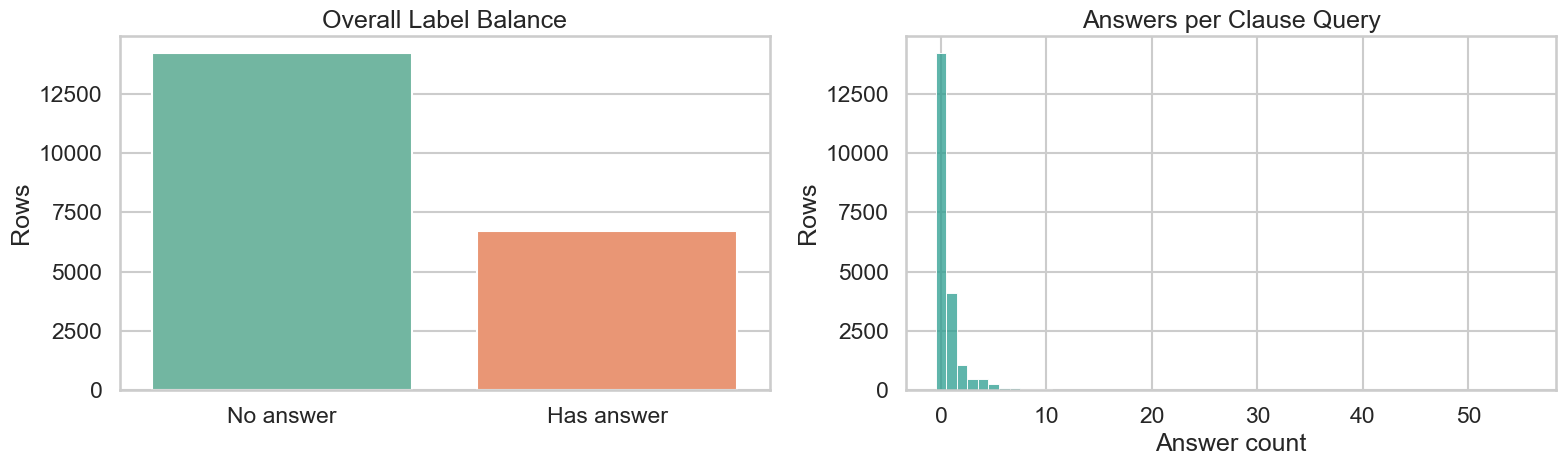

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

overall_balance = cuad_df["has_answer"].value_counts().rename(index={True: "Has answer", False: "No answer"})
sns.barplot(x=overall_balance.index, y=overall_balance.values, ax=axes[0], palette="Set2")
axes[0].set_title("Overall Label Balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")

sns.histplot(cuad_df["answer_count"], bins=15, discrete=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Answers per Clause Query")
axes[1].set_xlabel("Answer count")
axes[1].set_ylabel("Rows")

plt.tight_layout()


/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_2609/2476789065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive_counts, x="positive_rows", y=top_positive_counts.index, ax=axes[0], palette="crest")
/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_2609/2476789065.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_positive_rates, x="positive_rate", y=top_positive_rates.index, ax=axes[1], palette="flare")


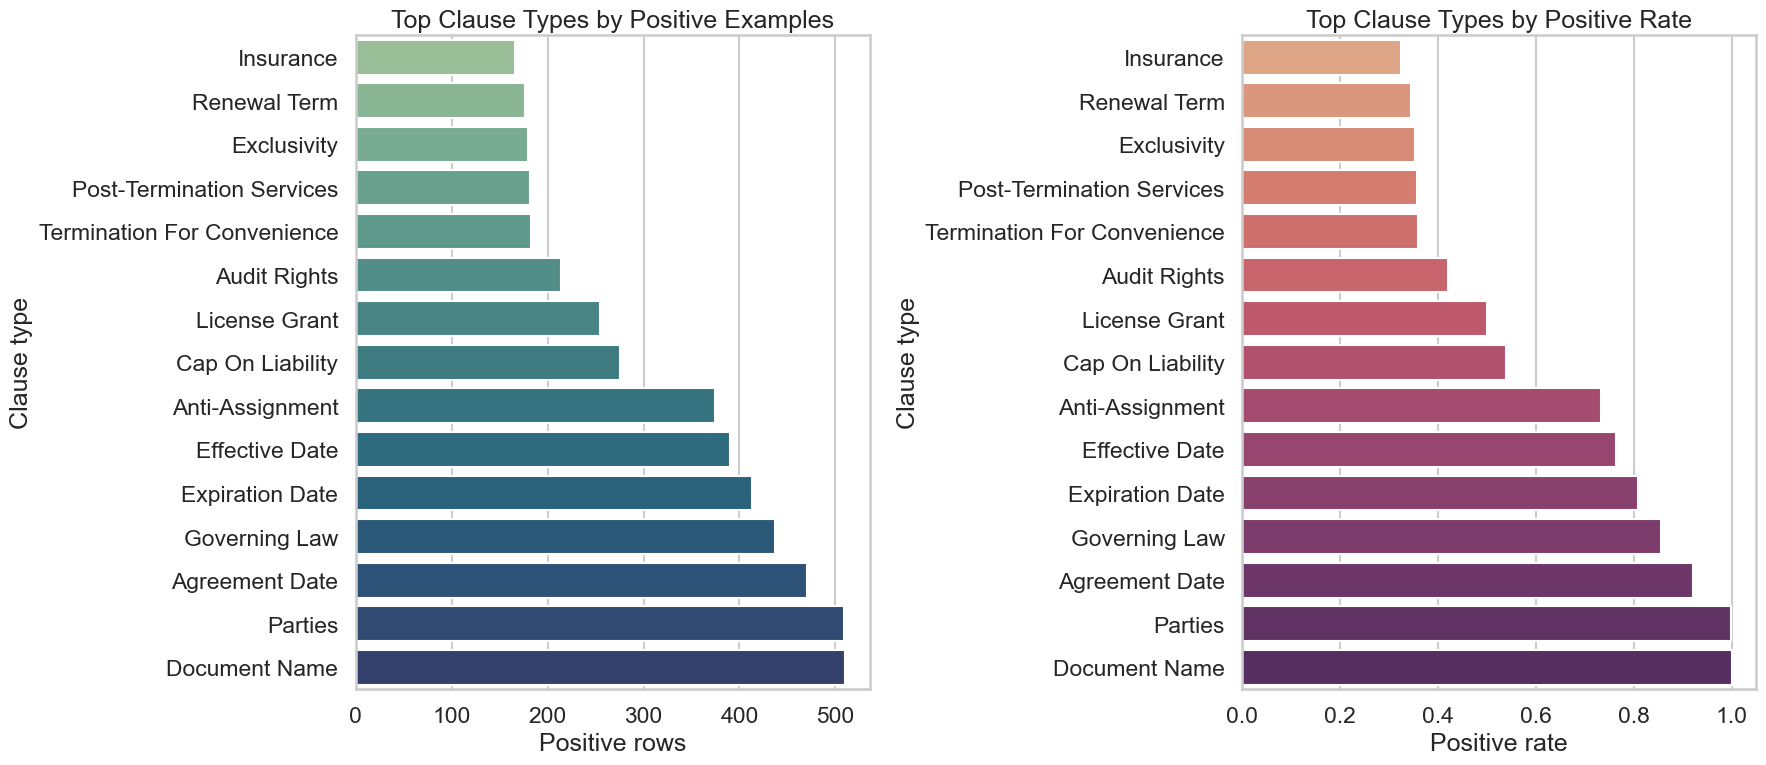

In [10]:
top_positive_counts = clause_summary.head(15).sort_values("positive_rows")
top_positive_rates = clause_summary.sort_values("positive_rate", ascending=False).head(15).sort_values("positive_rate")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=top_positive_counts, x="positive_rows", y=top_positive_counts.index, ax=axes[0], palette="crest")
axes[0].set_title("Top Clause Types by Positive Examples")
axes[0].set_xlabel("Positive rows")
axes[0].set_ylabel("Clause type")

sns.barplot(data=top_positive_rates, x="positive_rate", y=top_positive_rates.index, ax=axes[1], palette="flare")
axes[1].set_title("Top Clause Types by Positive Rate")
axes[1].set_xlabel("Positive rate")
axes[1].set_ylabel("Clause type")

plt.tight_layout()


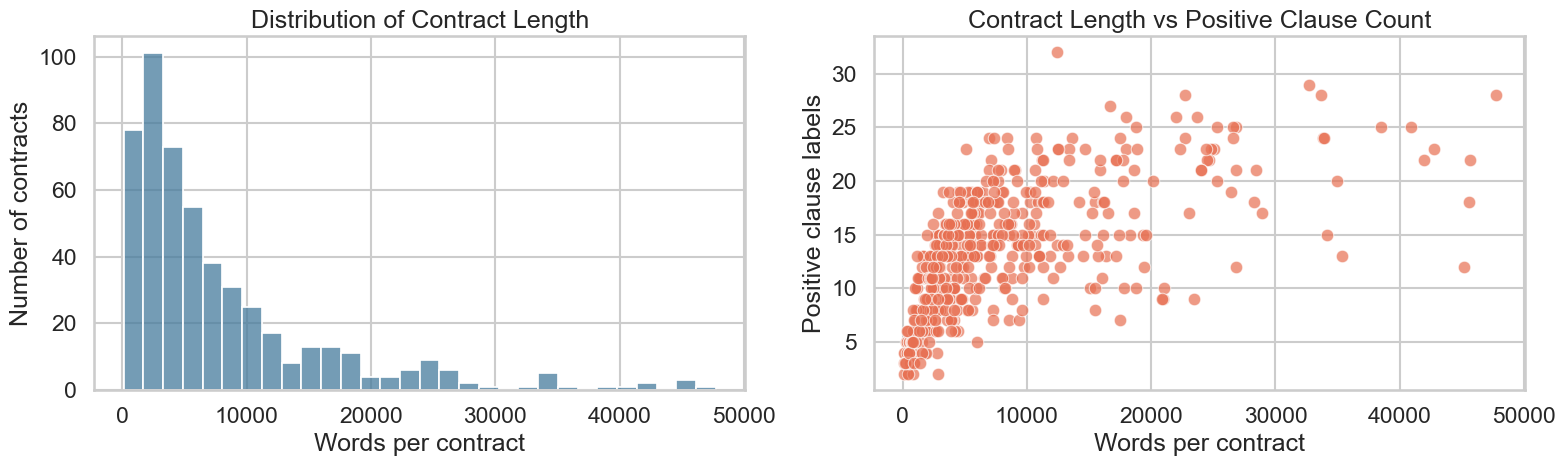

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(contract_df["contract_word_count"], bins=30, ax=axes[0], color="#457b9d")
axes[0].set_title("Distribution of Contract Length")
axes[0].set_xlabel("Words per contract")
axes[0].set_ylabel("Number of contracts")

sns.scatterplot(
    data=contract_positive_counts,
    x="contract_word_count",
    y="positive_clause_count",
    ax=axes[1],
    alpha=0.7,
    color="#e76f51",
)
axes[1].set_title("Contract Length vs Positive Clause Count")
axes[1].set_xlabel("Words per contract")
axes[1].set_ylabel("Positive clause labels")

plt.tight_layout()


/var/folders/zr/hq_q97d52l1ck8p_4myglv4r0000gn/T/ipykernel_2609/3233914451.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_answers_per_clause, x="avg_answer_count", y=avg_answers_per_clause.index, ax=axes[1], palette="mako")


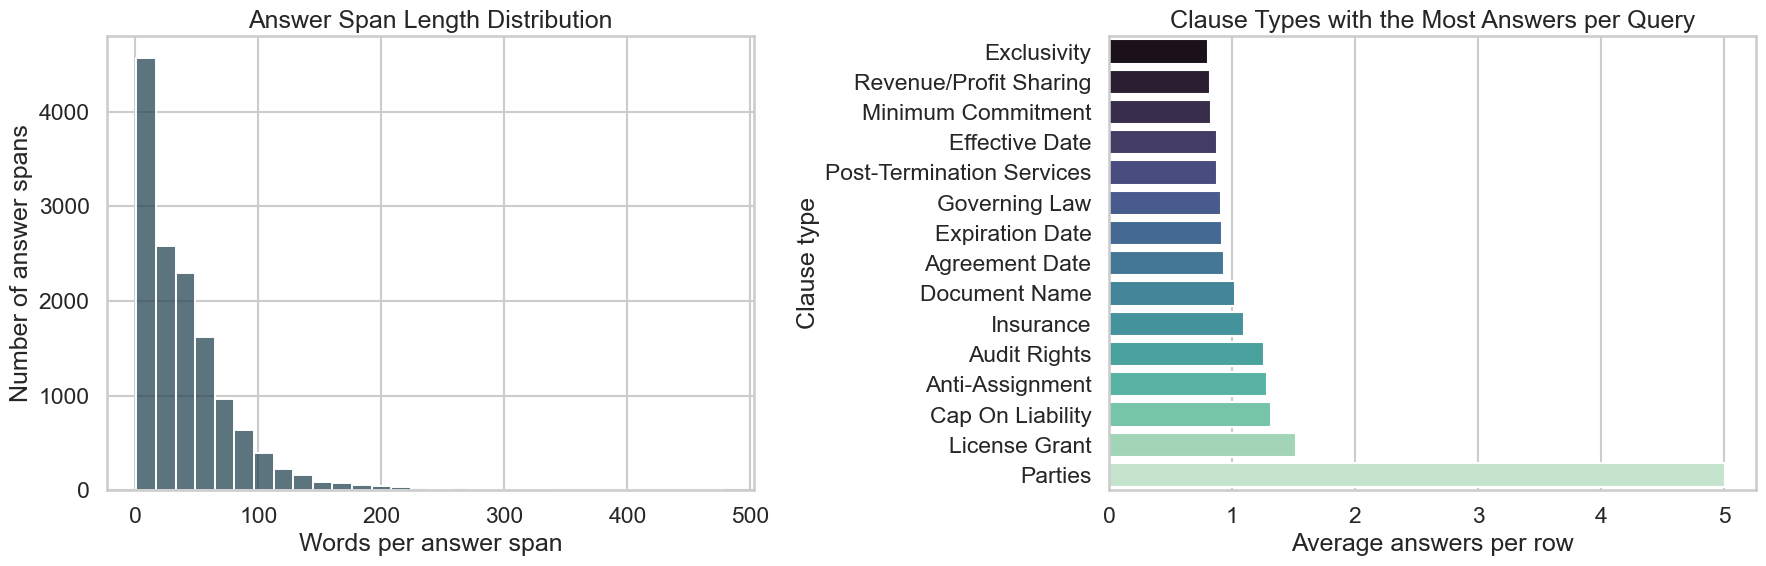

In [12]:
avg_answers_per_clause = clause_summary.sort_values("avg_answer_count", ascending=False).head(15).sort_values("avg_answer_count")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(answer_spans_df["answer_span_word_count"], bins=30, ax=axes[0], color="#264653")
axes[0].set_title("Answer Span Length Distribution")
axes[0].set_xlabel("Words per answer span")
axes[0].set_ylabel("Number of answer spans")

sns.barplot(data=avg_answers_per_clause, x="avg_answer_count", y=avg_answers_per_clause.index, ax=axes[1], palette="mako")
axes[1].set_title("Clause Types with the Most Answers per Query")
axes[1].set_xlabel("Average answers per row")
axes[1].set_ylabel("Clause type")

plt.tight_layout()


In [13]:
clause_summary.sort_values(["positive_rate", "positive_rows"], ascending=[False, False])


,total_rows,positive_rows,positive_rate,avg_answer_count
clause_type,,,,
Document Name,510,510,1.000000,1.021569
Parties,510,509,0.998039,5.007843
Agreement Date,510,470,0.921569,0.933333
Governing Law,510,437,0.856863,0.909804
Expiration Date,510,413,0.809804,0.915686
Effective Date,510,390,0.764706,0.876471
Anti-Assignment,510,374,0.733333,1.282353
Cap On Liability,510,275,0.539216,1.317647
License Grant,510,255,0.500000,1.523529


## Chunk-Level Multi-Label Clause Classifier

Instead of asking 41 separate questions per chunk, we can turn each chunk into a single multi-label example with a 41-dimensional target vector. The cells below build chunk labels directly from CUAD answer spans and train one classifier that predicts all clause labels in one forward pass.


In [14]:
import importlib
import cuad_chunk_multilabel

importlib.reload(cuad_chunk_multilabel)

from cuad_chunk_multilabel import (
    evaluate_chunk_classifier,
    make_chunk_dataframe,
    predict_contract_chunks,
    prepare_chunked_splits,
    train_chunk_classifier,
)

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
STRIDE = 64
SEED = 42

PREVIEW_MAX_TRAIN_BATCHES = 60
PREVIEW_MAX_VAL_BATCHES = 10
PREVIEW_MAX_TEST_BATCHES = 20


In [15]:
chunk_artifacts = prepare_chunked_splits(
    cuad_df,
    model_name=MODEL_NAME,
    max_length=MAX_LENGTH,
    stride=STRIDE,
    seed=SEED,
)

train_chunk_df = make_chunk_dataframe(chunk_artifacts["train_examples"], chunk_artifacts["id_to_clause"])
val_chunk_df = make_chunk_dataframe(chunk_artifacts["val_examples"], chunk_artifacts["id_to_clause"])
test_chunk_df = make_chunk_dataframe(chunk_artifacts["test_examples"], chunk_artifacts["id_to_clause"])

print(f"Train chunks: {len(train_chunk_df):,}")
print(f"Validation chunks: {len(val_chunk_df):,}")
print(f"Test chunks: {len(test_chunk_df):,}")
print(f"Label count: {len(chunk_artifacts['id_to_clause'])}")

train_chunk_df.head()


Train chunks: 23,521
Validation chunks: 2,846
Test chunks: 2,820
Label count: 41


,contract_title,chunk_index,chunk_char_start,chunk_char_end,chunk_text,num_active_labels,active_labels
0,InnerscopeHearingTechnologiesInc_20181109_8-K_...,0,0,1203,Exhibit 10.6 ATTACHMENT A ERCHONIA CORPORATION...,5,"[Document Name, Exclusivity, License Grant, No..."
1,InnerscopeHearingTechnologiesInc_20181109_8-K_...,1,891,2172,distribute the Products pursuant to the terms ...,3,"[Exclusivity, License Grant, Non-Transferable ..."
2,InnerscopeHearingTechnologiesInc_20181109_8-K_...,2,1865,3108,"Distributor will deliver, at Erchonia's expens...",1,[Minimum Commitment]
3,InnerscopeHearingTechnologiesInc_20181109_8-K_...,3,2808,4101,or (ii) shall give Erchonia to terminate or li...,2,"[Audit Rights, Minimum Commitment]"
4,InnerscopeHearingTechnologiesInc_20181109_8-K_...,4,3820,5159,pay for all products purchased in a timely man...,1,[License Grant]


In [16]:
chunk_label_summary = (
    train_chunk_df.explode("active_labels")
    .dropna(subset=["active_labels"])
    ["active_labels"]
    .value_counts()
    .rename_axis("clause_type")
    .to_frame("positive_chunks")
)

display(train_chunk_df[["num_active_labels"]].describe())
display(chunk_label_summary.head(15))


,num_active_labels
count,23521.000000
mean,0.515242
std,0.913867
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,8.000000


,positive_chunks
clause_type,
License Grant,832
Cap On Liability,707
Anti-Assignment,657
Parties,624
Governing Law,576
Audit Rights,572
Expiration Date,556
Post-Termination Services,504
Minimum Commitment,490


In [20]:
# Preview run: keep training intentionally small so we can inspect output shape quickly.
training_output = train_chunk_classifier(
    train_dataset=chunk_artifacts["train_dataset"],
    val_dataset=chunk_artifacts["val_dataset"],
    train_examples=chunk_artifacts["train_examples"],
    model_name=MODEL_NAME,
    tokenizer=chunk_artifacts["tokenizer"],
    id_to_clause=chunk_artifacts["id_to_clause"],
    epochs=3,
    batch_size=16,
    learning_rate=2e-5,
    max_train_batches=PREVIEW_MAX_TRAIN_BATCHES,
    max_val_batches=PREVIEW_MAX_VAL_BATCHES,
)

print(f"Best validation threshold: {training_output.best_threshold:.2f}")
training_output.history


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 684.50it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Best validation threshold: 0.50


,epoch,train_loss,val_threshold,micro_f1,macro_f1,samples_f1,micro_precision,micro_recall,subset_accuracy,hamming_loss
0,1,1.309054,0.5,0.046951,0.031778,0.042940,0.024321,0.675439,0.0,0.476524
1,2,1.435895,0.5,0.048403,0.033473,0.044628,0.025126,0.657895,0.0,0.449543
2,3,1.401958,0.5,0.046279,0.044578,0.043136,0.023995,0.649123,0.0,0.464939


In [21]:
test_metrics = evaluate_chunk_classifier(
    model=training_output.model,
    dataset=chunk_artifacts["test_dataset"],
    threshold=training_output.best_threshold,
    max_batches=PREVIEW_MAX_TEST_BATCHES,
)

pd.Series(test_metrics).sort_index()


hamming_loss       0.456479
macro_f1           0.033797
micro_f1           0.047096
micro_precision    0.024471
micro_recall       0.624473
samples_f1         0.043907
subset_accuracy    0.000000
dtype: float64

In [22]:
sample_contract = chunk_artifacts["test_records"][0]["contract_text"]

sample_predictions = predict_contract_chunks(
    contract_text=sample_contract,
    model=training_output.model,
    tokenizer=chunk_artifacts["tokenizer"],
    id_to_clause=chunk_artifacts["id_to_clause"],
    threshold=training_output.best_threshold,
    max_length=MAX_LENGTH,
    stride=STRIDE,
)

sample_predictions[sample_predictions["predicted_labels"].str.len() > 0][
    ["chunk_index", "predicted_labels", "chunk_text"]
].head(10)


,chunk_index,predicted_labels,chunk_text
0,0,"[Anti-Assignment, Cap On Liability, Change Of ...","Exhibit 4.15 THE SYMBOL ""****"" DENOTES PLACES ..."
1,1,"[Anti-Assignment, Cap On Liability, Change Of ...",; WHEREAS: Kitov is a pharmaceutical company e...
2,2,"[Anti-Assignment, Change Of Control, Competiti...","the following: 1.1 ""Affiliate"" of a Party shal..."
3,3,"[Anti-Assignment, Change Of Control, Competiti...","size for the Product is **** tablets. 1.5 ""cGM..."
4,4,"[Anti-Assignment, Cap On Liability, Change Of ...",such Party (and/or any corporate entity that C...
5,5,"[Anti-Assignment, Cap On Liability, Change Of ...",", initiated or made by any governmental author..."
6,6,"[Anti-Assignment, Change Of Control, Competiti...",the Product in a certain territory or territor...
7,7,"[Anti-Assignment, Cap On Liability, Change Of ...",", insurrection, military or usurped power or c..."
8,8,"[Anti-Assignment, Change Of Control, Competiti...","improvements, enhancements, derivatives and re..."
9,9,"[Anti-Assignment, Change Of Control, Competiti...",", ""Labeled"" or ""Labeling"" shall refer to: (i) ..."
